# Teste Técnico - Analista de Dados
## Dataset: Car Insurance Claim

### Objetivo
Analisar a taxa de sinistro (`OUTCOME`) por segmentos e identificar fatores associados a maior risco, gerando insights para apoiar decisões de precificação, underwriting e retenção.

O foco da análise será:
- Entender o comportamento da variável alvo (`OUTCOME`)
- Identificar padrões de risco por perfil de cliente
- Gerar recomendações práticas de negócio

# 2. Leitura da base

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

df = pd.read_csv('/content/Car_Insurance_Claim.csv')

df.head()

,ID,AGE,GENDER,RACE,DRIVING_EXPERIENCE,EDUCATION,INCOME,CREDIT_SCORE,VEHICLE_OWNERSHIP,VEHICLE_YEAR,MARRIED,CHILDREN,POSTAL_CODE,ANNUAL_MILEAGE,VEHICLE_TYPE,SPEEDING_VIOLATIONS,DUIS,PAST_ACCIDENTS,OUTCOME
0,569520,65+,female,majority,0-9y,high school,upper class,0.629027,1.0,after 2015,0.0,1.0,10238,12000.0,sedan,0,0,0,0.0
1,750365,16-25,male,majority,0-9y,none,poverty,0.357757,0.0,before 2015,0.0,0.0,10238,16000.0,sedan,0,0,0,1.0
2,199901,16-25,female,majority,0-9y,high school,working class,0.493146,1.0,before 2015,0.0,0.0,10238,11000.0,sedan,0,0,0,0.0
3,478866,16-25,male,majority,0-9y,university,working class,0.206013,1.0,before 2015,0.0,1.0,32765,11000.0,sedan,0,0,0,0.0
4,731664,26-39,male,majority,10-19y,none,working class,0.388366,1.0,before 2015,0.0,0.0,32765,12000.0,sedan,2,0,1,1.0


# 3. Visão geral e auditoria

In [88]:
print("Linhas:", df.shape[0])
print("Colunas:", df.shape[1])

Linhas: 10000
Colunas: 19


In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   10000 non-null  int64  
 1   AGE                  10000 non-null  object 
 2   GENDER               10000 non-null  object 
 3   RACE                 10000 non-null  object 
 4   DRIVING_EXPERIENCE   10000 non-null  object 
 5   EDUCATION            10000 non-null  object 
 6   INCOME               10000 non-null  object 
 7   CREDIT_SCORE         9018 non-null   float64
 8   VEHICLE_OWNERSHIP    10000 non-null  float64
 9   VEHICLE_YEAR         10000 non-null  object 
 10  MARRIED              10000 non-null  float64
 11  CHILDREN             10000 non-null  float64
 12  POSTAL_CODE          10000 non-null  int64  
 13  ANNUAL_MILEAGE       9043 non-null   float64
 14  VEHICLE_TYPE         10000 non-null  object 
 15  SPEEDING_VIOLATIONS  10000 non-null  

In [90]:
df.isnull().sum().sort_values(ascending=False)

,0
CREDIT_SCORE,982
ANNUAL_MILEAGE,957
ID,0
GENDER,0
AGE,0
EDUCATION,0
RACE,0
INCOME,0
VEHICLE_OWNERSHIP,0
VEHICLE_YEAR,0


In [91]:
df.duplicated().sum()

np.int64(0)

In [92]:
df['OUTCOME'].value_counts(normalize=True)

,proportion
OUTCOME,
0.0,0.6867
1.0,0.3133


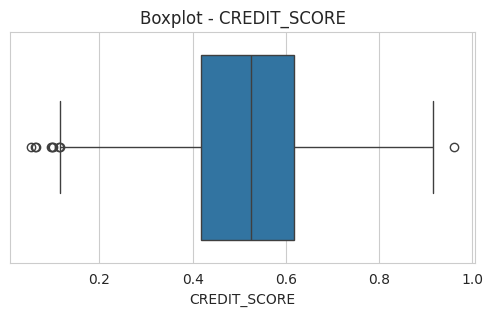

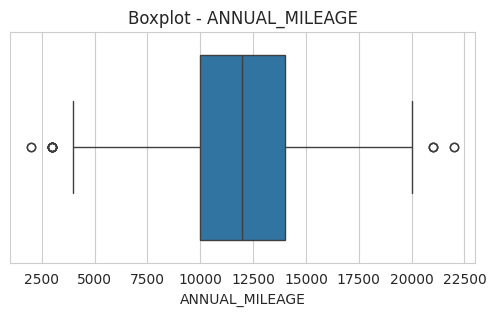

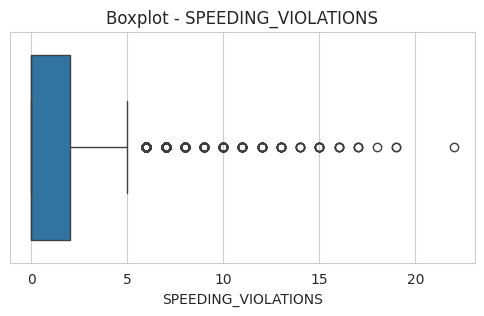

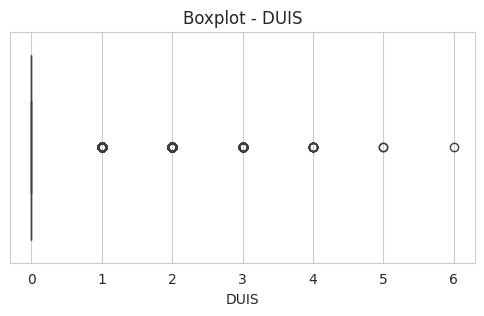

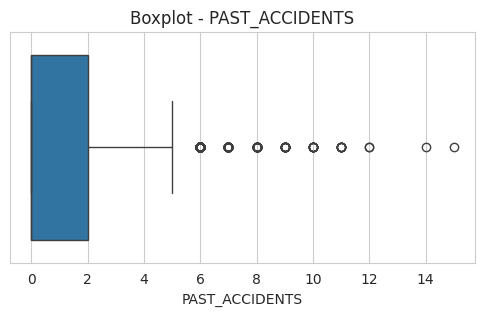

In [93]:
cols_outliers = ['CREDIT_SCORE', 'ANNUAL_MILEAGE', 'SPEEDING_VIOLATIONS', 'DUIS', 'PAST_ACCIDENTS']

for col in cols_outliers:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot - {col}')
    plt.show()

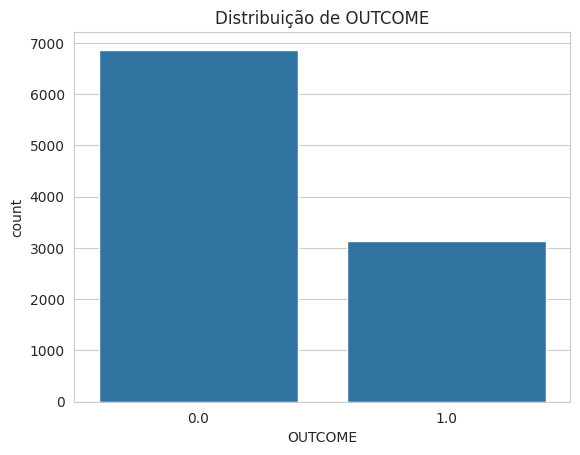

In [94]:
sns.countplot(data=df, x='OUTCOME')
plt.title('Distribuição de OUTCOME')
plt.show()

## Auditoria inicial

O dataset possui 10.000 registros e 19 colunas, contendo informações demográficas, perfil financeiro, histórico de direção e características do veículo.

Foram identificados valores ausentes principalmente nas variáveis `CREDIT_SCORE` e `ANNUAL_MILEAGE`.

Não foram encontrados registros duplicados.

## Balanceamento da variável alvo

A variável `OUTCOME` apresenta leve desbalanceamento, com predominância de clientes sem sinistro.

No entanto, a proporção de eventos positivos (~31%) é suficiente para análise exploratória, não sendo necessário aplicar técnicas de balanceamento neste momento.

## Análise de outliers

Foram identificados valores extremos principalmente nas variáveis relacionadas ao comportamento de risco, como multas, DUI e acidentes passados.

Esses valores são esperados nesse contexto, representando clientes com maior exposição ao risco, e por isso não foram removidos da base.

# 4. Tratamento dos dados

In [95]:
df_tratado = df.copy()

df_tratado['CREDIT_SCORE'] = df_tratado['CREDIT_SCORE'].fillna(df_tratado['CREDIT_SCORE'].median())
df_tratado['ANNUAL_MILEAGE'] = df_tratado['ANNUAL_MILEAGE'].fillna(df_tratado['ANNUAL_MILEAGE'].median())

## Estratégia de tratamento

Os valores ausentes nas variáveis `CREDIT_SCORE` e `ANNUAL_MILEAGE` foram preenchidos utilizando a mediana.

A escolha da mediana se deve ao fato dessas variáveis apresentarem possíveis distribuições assimétricas e presença de valores extremos, tornando a média menos robusta.

Essa abordagem permite preservar o volume de dados sem introduzir distorções relevantes na distribuição.

# 5. KPIs principais

In [96]:
total_clientes = len(df_tratado)
total_sinistros = int(df_tratado['OUTCOME'].sum())
taxa_sinistro = df_tratado['OUTCOME'].mean()

print("Total de clientes:", total_clientes)
print("Total de sinistros:", total_sinistros)
print("Taxa de sinistro:", round(taxa_sinistro * 100, 2), "%")

Total de clientes: 10000
Total de sinistros: 3133
Taxa de sinistro: 31.33 %


# 6. Análise por segmento

In [97]:
def taxa_por_categoria(df, coluna):
    tabela = df.groupby(coluna, observed=False).agg(
        clientes=('OUTCOME', 'count'),
        sinistros=('OUTCOME', 'sum'),
        taxa_sinistro=('OUTCOME', 'mean')
    ).reset_index().sort_values(by='taxa_sinistro', ascending=False)

    tabela['taxa_sinistro'] = (tabela['taxa_sinistro'] * 100).round(2)
    return tabela

In [98]:
idade = taxa_por_categoria(df_tratado, 'AGE')
idade

,AGE,clientes,sinistros,taxa_sinistro
0,16-25,2016,1448.0,71.83
1,26-39,3063,1032.0,33.69
2,40-64,2931,457.0,15.59
3,65+,1990,196.0,9.85


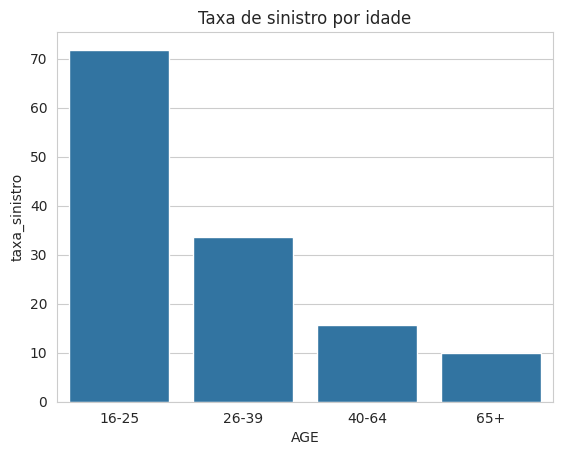

In [99]:
sns.barplot(data=idade, x='AGE', y='taxa_sinistro')
plt.title('Taxa de sinistro por idade')
plt.show()

In [100]:
exp = taxa_por_categoria(df_tratado, 'DRIVING_EXPERIENCE')
exp

,DRIVING_EXPERIENCE,clientes,sinistros,taxa_sinistro
0,0-9y,3530,2217.0,62.80
1,10-19y,3299,787.0,23.86
2,20-29y,2119,109.0,5.14
3,30y+,1052,20.0,1.90


In [101]:
renda = taxa_por_categoria(df_tratado, 'INCOME')
renda

,INCOME,clientes,sinistros,taxa_sinistro
1,poverty,1814,1186.0,65.38
3,working class,1712,776.0,45.33
0,middle class,2138,592.0,27.69
2,upper class,4336,579.0,13.35


In [102]:
veiculo = taxa_por_categoria(df_tratado, 'VEHICLE_TYPE')
veiculo

,VEHICLE_TYPE,clientes,sinistros,taxa_sinistro
1,sports car,477,155.0,32.49
0,sedan,9523,2978.0,31.27


In [103]:
df_tratado['MILEAGE_FAIXA'] = pd.qcut(
    df_tratado['ANNUAL_MILEAGE'],
    q=4,
    labels=['Baixa', 'Média-Baixa', 'Média-Alta', 'Alta']
)

taxa_por_categoria(df_tratado, 'MILEAGE_FAIXA')

,MILEAGE_FAIXA,clientes,sinistros,taxa_sinistro
3,Alta,2360,1028.0,43.56
2,Média-Alta,1137,389.0,34.21
1,Média-Baixa,3428,1019.0,29.73
0,Baixa,3075,697.0,22.67


In [104]:
def faixa_multas(x):
    if x == 0:
        return '0'
    elif x <= 2:
        return '1-2'
    elif x <= 5:
        return '3-5'
    else:
        return '6+'

df_tratado['MULTAS_FAIXA'] = df_tratado['SPEEDING_VIOLATIONS'].apply(faixa_multas)

taxa_por_categoria(df_tratado, 'MULTAS_FAIXA')

,MULTAS_FAIXA,clientes,sinistros,taxa_sinistro
0,0,5028,2472.0,49.16
1,1-2,2705,442.0,16.34
2,3-5,1679,175.0,10.42
3,6+,588,44.0,7.48


In [105]:
def faixa_dui(x):
    if x == 0:
        return '0'
    else:
        return '1+'

df_tratado['DUI_FAIXA'] = df_tratado['DUIS'].apply(faixa_dui)

taxa_por_categoria(df_tratado, 'DUI_FAIXA')

,DUI_FAIXA,clientes,sinistros,taxa_sinistro
0,0,8118,2914.0,35.90
1,1+,1882,219.0,11.64


## Análise geral dos segmentos

Observa-se variação relevante na taxa de sinistro entre diferentes perfis de clientes.

Segmentos com menor experiência de direção e determinados perfis socioeconômicos apresentam maior incidência de sinistros, indicando possível correlação com comportamento de risco.

# 7. Drivers de risco

In [106]:
df_tratado['CREDIT_SCORE_FAIXA'] = pd.qcut(
    df_tratado['CREDIT_SCORE'],
    q=4,
    labels=['Baixo', 'Médio-Baixo', 'Médio-Alto', 'Alto']
)

taxa_por_categoria(df_tratado, 'CREDIT_SCORE_FAIXA')

## disclaimer: Observa-se uma relação clara entre score de crédito e taxa de sinistro. Clientes na faixa de menor score apresentam risco substancialmente superior aos de score mais alto, sugerindo que essa variável pode ser relevante para decisões de precificação e underwriting.

,CREDIT_SCORE_FAIXA,clientes,sinistros,taxa_sinistro
0,Baixo,2500,1336.0,53.44
1,Médio-Baixo,2991,981.0,32.80
2,Médio-Alto,2009,435.0,21.65
3,Alto,2500,381.0,15.24


In [107]:
def faixa_acidentes(x):
    if x == 0:
        return '0'
    elif x == 1:
        return '1'
    elif x <= 3:
        return '2-3'
    else:
        return '4+'

df_tratado['PAST_ACCIDENTS_FAIXA'] = df_tratado['PAST_ACCIDENTS'].apply(faixa_acidentes)

taxa_por_categoria(df_tratado, 'PAST_ACCIDENTS_FAIXA')

,PAST_ACCIDENTS_FAIXA,clientes,sinistros,taxa_sinistro
0,0,5584,2623.0,46.97
1,1,1783,268.0,15.03
2,2-3,1750,198.0,11.31
3,4+,883,44.0,4.98


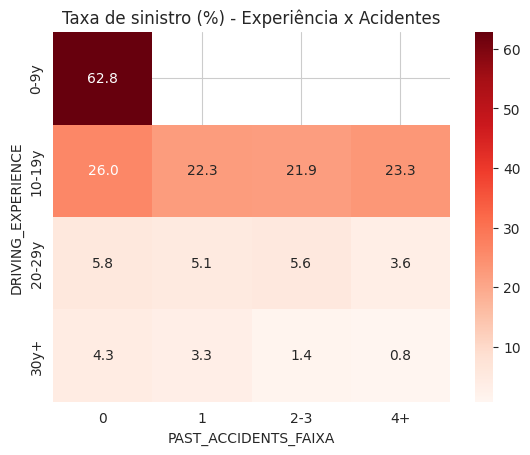

In [108]:
heatmap_df = pd.pivot_table(
    df_tratado,
    values='OUTCOME',
    index='DRIVING_EXPERIENCE',
    columns='PAST_ACCIDENTS_FAIXA',
    aggfunc='mean'
)

sns.heatmap(heatmap_df * 100, annot=True, fmt='.1f', cmap='Reds')
plt.title('Taxa de sinistro (%) - Experiência x Acidentes')
plt.show()

## Análise de drivers de risco

O histórico de acidentes e a experiência de direção se destacam como fatores relevantes para explicação do risco.

Clientes com menor experiência e maior histórico de acidentes apresentam significativamente maior probabilidade de sinistro, indicando comportamento recorrente de risco.

# 8. Principais insights

1. Clientes com baixo credit score apresentam taxa de sinistro superior a 50%, mais de 3x maior que clientes com score alto (~15%), indicando forte relevância dessa variável para precificação.

2. O histórico de acidentes aumenta significativamente o risco, com crescimento progressivo da taxa de sinistro conforme o número de ocorrências.

3. Clientes com menor experiência de direção apresentam maior incidência de sinistros, indicando maior exposição ao risco.

4. Maior quilometragem anual está associada a maior taxa de sinistro, sugerindo impacto direto da exposição ao uso do veículo.

5. Infrações como multas e DUI elevam substancialmente o risco, reforçando o comportamento do condutor como fator crítico.

# 9. Próximos passos / recomendações

- Ajustar precificação para clientes com histórico de acidentes.
- Criar políticas de underwriting mais rigorosas para perfis de alto risco.
- Incentivar comportamentos seguros com benefícios para clientes de baixo risco.
- Monitorar clientes com alto volume de quilometragem anual.
- Utilizar modelos preditivos para antecipação de risco.

In [109]:
df_tratado.to_csv('base_tratada.csv', index=False)